### Data description

Data comes from Jet Propulsion Laboratory Small-Body Database Query: https://ssd.jpl.nasa.gov/tools/sbdb_query.html

Dataset has 30 columns:
- diameter - diameter of the asteroid [target]
- full_name - Object full name
- a - semi-major axis
- e - eccentricity
- i - inclination with respect to x-y ecliptic plane(deg)
- om - longitude of the ascending node
- w - argument of perihelion
- q - perihelion distance(au)
- ad - aphelion distance(au)
- per_y - orbital periond(years)
- data_arc - data arc span(d)
- condition_code - orbit condition code
- n_obs_used - number of observation used
- H - absolute magnitude parameter
- neo - Near Earth Object
- pha - Physically Hazardous Asteroid
- extent - Object bi/tri axial ellipsoid dimensions(km)
- albedo - geometric albedo
- rot_per - rotation period(h)
- GM - standard gravitational parameter, Product of mass and gravitational constant
- BV - Color index B-V magnitude difference
- UB - Color index U-B magnitude difference
- IR - Color index I-R magnitude difference
- spec_B - Spectral taxonomic type(SMASSII)
- spec_T - Spectral taxonomic type(Tholen)
- G - magnitude slope parameter
- moid - Earth Minimum orbit Intersection Distance(au)
- class - asteroid orbit class
- n - mean motion(deg/d)
- ma - mean anomaly(deg)

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
def null_percentage(df: pd.DataFrame, col_name: str) -> float:
    return round(df[col_name].isna().sum() / len(df) * 100, 2)

## Load the data

In [64]:
df = pd.read_csv('data/raw/asteroid_dataset.csv', low_memory=False)
df = df.copy()
df.T

,0,1,2,3,4,5,6,7,8,9,...,1474958,1474959,1474960,1474961,1474962,1474963,1474964,1474965,1474966,1474967
full_name,1 Ceres (A801 AA),2 Pallas (A802 FA),3 Juno (A804 RA),4 Vesta (A807 FA),5 Astraea (A845 XA),6 Hebe (A847 NA),7 Iris (A847 PA),8 Flora (A847 UA),9 Metis (A848 HA),10 Hygiea (A849 GA),...,C/2025 N1 (ATLAS),C/2025 N2 (ATLAS),C/2025 O2 (MAPS),C/2025 Q1 (ATLAS),P/2025 Q2 (PANSTARRS),C/2025 Q3 (ATLAS),C/2025 R1 (ATLAS),C/2025 R2 (SWAN),C/2025 R3 (PANSTARRS),C/2025 T1 (ATLAS)
a,2.766,2.77,2.671,2.362,2.577,2.425,2.387,2.201,2.387,3.148,...,-0.264,-4172.0,2017.0,1157.0,3.012,742.2,167.3,75.32,17220.0,273.3
e,0.0796,0.2306,0.2558,0.0902,0.1875,0.2022,0.2302,0.1563,0.1226,0.1082,...,6.1374,1.0022,0.9989,0.9913,0.2378,0.9972,0.9882,0.9933,1.0,0.9959
i,10.59,34.93,12.99,7.14,5.36,14.74,5.52,5.89,5.58,3.83,...,175.11,81.66,134.54,66.15,14.78,90.19,110.03,4.47,124.71,123.47
om,80.25,172.89,169.82,103.7,141.45,138.61,259.49,110.84,68.87,283.12,...,322.15,94.46,332.31,326.97,271.04,233.14,60.4,335.35,38.68,140.53
w,73.3,310.93,247.88,151.54,359.35,239.7,145.48,285.43,5.9,312.61,...,128.01,230.1,280.24,280.24,81.14,218.45,77.55,308.31,162.27,114.26
q,2.546,2.131,1.988,2.149,2.094,1.935,1.837,1.857,2.094,2.807,...,1.356,8.984,2.289,10.1,2.296,2.113,1.975,0.504,0.498,1.108
ad,2.99,3.41,3.35,2.57,3.06,2.92,2.94,2.55,2.68,3.49,...,NaN,NaN,4032.63,2304.11,3.73,1482.31,332.61,150.14,34444.29,545.5
per_y,4.6,4.61,4.37,3.63,4.14,3.78,3.69,3.27,3.69,5.58,...,NaN,NaN,90600.0,39400.0,5.23,20200.0,2160.0,654.0,2260000.0,4520.0
data_arc,9520.0,80696.0,80649.0,25743.0,65619.0,64264.0,64432.0,64929.0,64291.0,64360.0,...,129.0,77.0,54.0,2041.0,3580.0,56.0,29.0,50.0,25.0,6.0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474968 entries, 0 to 1474967
Data columns (total 30 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   full_name       1474968 non-null  object 
 1   a               1473206 non-null  float64
 2   e               1474968 non-null  float64
 3   i               1474968 non-null  float64
 4   om              1474968 non-null  float64
 5   w               1474968 non-null  float64
 6   q               1474968 non-null  float64
 7   ad              1472692 non-null  float64
 8   per_y           1472635 non-null  float64
 9   data_arc        1472643 non-null  float64
 10  condition_code  1472028 non-null  float64
 11  n_obs_used      1474897 non-null  float64
 12  H               1470353 non-null  float64
 13  diameter        139696 non-null   float64
 14  extent          23 non-null       object 
 15  albedo          138487 non-null   float64
 16  rot_per         34618 non-null    fl

In [66]:
df.shape

(1474968, 30)

## Data analysis

#### Target: diameter

In [67]:
df.diameter.dtype

dtype('float64')

In [68]:
df = df.dropna(subset=['diameter'])

In [69]:
df.shape

(139696, 30)

Text(0.5, 0, '')

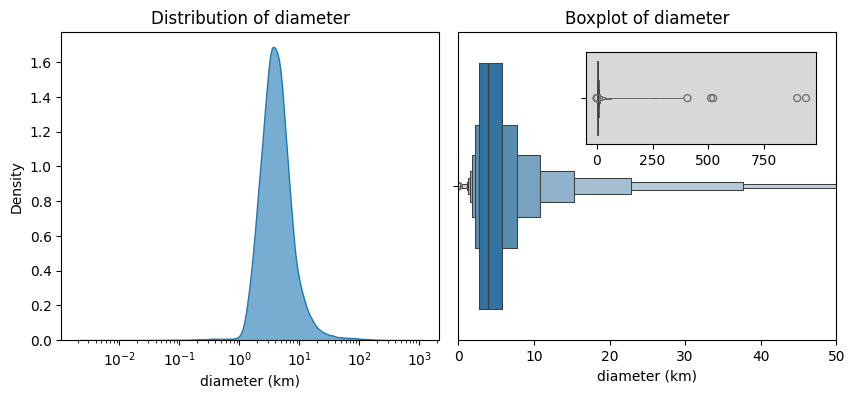

In [70]:
### Visualisation of diameter
fig = plt.figure(figsize=(10, 4))
plt.subplots_adjust(wspace=0.05)

plt.subplot(121, xlabel='diameter (km)', title='Distribution of diameter')
sns.kdeplot(data=df, x='diameter', fill=True, log_scale=True, alpha=0.6)

plt.subplot(122, title='Boxplot of diameter', xlim=(0, 50))
sns.boxenplot(data=df, x='diameter')
plt.gca().set(xlabel='diameter (km)')

fig.add_axes([0.65,0.6,0.23,0.23])
zoom_out_ax = sns.boxenplot(data=df, x='diameter', linewidth=.5)
zoom_out_ax.set_facecolor('#D8D8D8')
plt.xlabel('')

### Columns with too much missing data
Althought we see interesting columns describing spectral parameters (BV, UB, IR, spec_B, spec_T) as well as physical ones (extent, GM, G) and rotation period (rot_per), they have too much missing values to be of any use for model training. Because of that we drop them.

In [71]:
too_much_na = []
for col in df.columns:

    null_pctg = null_percentage(df, col)

    if null_pctg > 50:
        too_much_na.append((col, null_pctg))

too_much_na

[('extent', np.float64(99.98)),
 ('rot_per', np.float64(85.73)),
 ('GM', np.float64(99.99)),
 ('BV', np.float64(99.28)),
 ('UB', np.float64(99.31)),
 ('IR', np.float64(100.0)),
 ('spec_B', np.float64(98.99)),
 ('spec_T', np.float64(99.31)),
 ('G', np.float64(99.91))]

In [72]:
df = df.drop([c[0] for c in too_much_na], axis=1)

### Non-numeric columns

### Full name
We can safely assume that name of the asteroid doesn't impact it's diameter in any way, so we can drop that column.

In [73]:
df.full_name.isna().sum()

np.int64(0)

In [74]:
df.full_name.head()

0           1 Ceres (A801 AA)
1          2 Pallas (A802 FA)
2            3 Juno (A804 RA)
3           4 Vesta (A807 FA)
4         5 Astraea (A845 XA)
Name: full_name, dtype: object

In [75]:
df = df.drop(['full_name'], axis=1)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139696 entries, 0 to 1474159
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   a               139696 non-null  float64
 1   e               139696 non-null  float64
 2   i               139696 non-null  float64
 3   om              139696 non-null  float64
 4   w               139696 non-null  float64
 5   q               139696 non-null  float64
 6   ad              139696 non-null  float64
 7   per_y           139696 non-null  float64
 8   data_arc        139688 non-null  float64
 9   condition_code  139692 non-null  float64
 10  n_obs_used      139696 non-null  float64
 11  H               139148 non-null  float64
 12  diameter        139696 non-null  float64
 13  albedo          138485 non-null  float64
 14  epoch_mjd       139696 non-null  int64  
 15  ma              139696 non-null  float64
 16  neo             139610 non-null  object 
 17  pha           

### NEO and PHA
NEO (Near Earth Object) and PHA (Potentially Hazardous Asteroid) are boolean indicators whether the asteroids peryhelion is less than 1.3 AU (NEO) and whether its minimum orbit intersection distance with Earth is less than 0.05 AU and its absolute magnitude is 22 or brighter - it means that diameter is approximately larger than 140 meters (PHA).

In [81]:
null_percentage(df, 'neo'), null_percentage(df, 'pha')

(np.float64(0.06), np.float64(0.08))

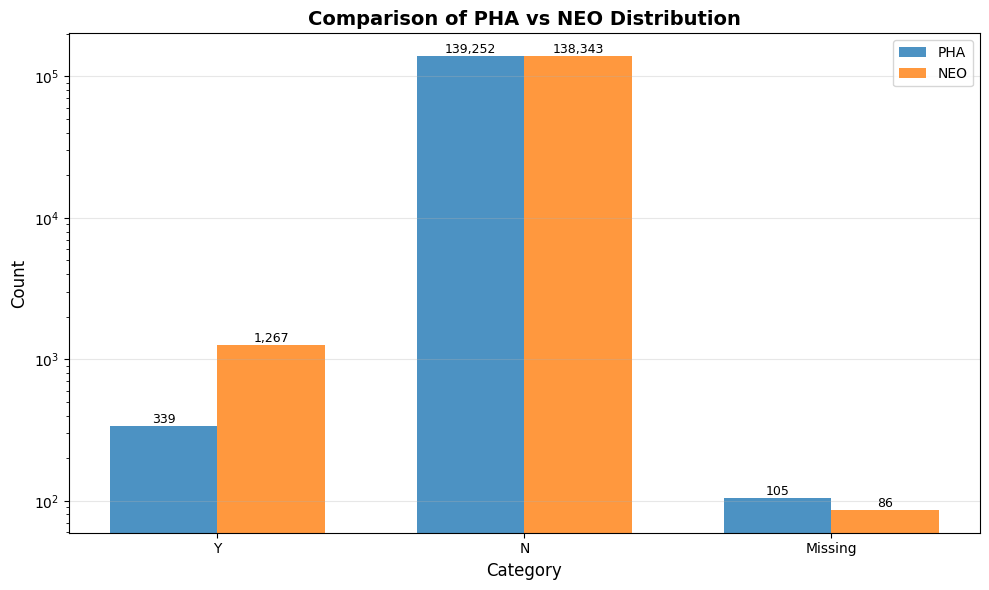

In [84]:
# Create comparison data for PHA and NEO
categories = ['Y', 'N', 'Missing']
pha_counts = [df_plot['pha_plot'].value_counts().get(cat, 0) for cat in categories]
neo_counts = [df_plot['neo_plot'].value_counts().get(cat, 0) for cat in categories]

# Create grouped bar plot
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, pha_counts, width, label='PHA', alpha=0.8)
bars2 = ax.bar(x + width/2, neo_counts, width, label='NEO', alpha=0.8)

# Add labels and formatting
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Comparison of PHA vs NEO Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.set_yscale('log')  # Using log scale due to large differences in counts
ax.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()